In [24]:
import torch
import torch.nn as nn
from torchvision import transforms, models
from torch.utils.data import Dataset
import pandas as pd
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
import random
import textwrap

# --- Model Selection Variable ---
# CHANGE THIS TO SELECT YOUR MODEL

# mobilenet_v3 was the best performing model so it is set as defualt

MODEL_TO_USE = 'mobilenet_v3' # Options: 'resnet50', 'mobilenet_v3', 'efficientnet_b2', 'convnext_tiny', 'vit_b_16'
# --------------------------------

# --- Configuration (Must match your training setup) ---
BASE_DIR = os.getcwd() # Assumes you run this from the project root
DATA_FOLDER_NAME = "Mosquito_Data"
ROOT_DATA_PATH = os.path.join(BASE_DIR, DATA_FOLDER_NAME)
IMAGE_FOLDER_PATH = os.path.join(ROOT_DATA_PATH, "Sample_Images")

CLEAN_MANIFEST_PATH = os.path.join(ROOT_DATA_PATH, "Sample_manifest.csv")
GLOSSARY_PATH = os.path.join(ROOT_DATA_PATH, "glossary.csv")

FILENAME_COLUMN = "image_path"
EXTRA_COLUMN_TO_DROP = "mosquito_id"
IMAGE_EXTENSION = ""

# Load and prepare glossary/data structures
try:
    glossary_df = pd.read_csv(GLOSSARY_PATH).set_index('feature_id')
    NUM_OUTPUTS = 256 # Assumes one 'check' and one 'value' output per feature
except FileNotFoundError:
    print(f"Error: Glossary file not found at {GLOSSARY_PATH}. Cannot determine output size.")
    NUM_OUTPUTS = 256 # Default or placeholder value
except KeyError:
    print("Error: Glossary file missing 'feature_id' column.")
    NUM_OUTPUTS = 256

ENTOMOLOGIST REPORT (Model: MOBILENET_V3)
Image Index in CSV: 2
------------------------------------------------------------

OBSERVABLE FEATURE PREDICTIONS (Sorted by Value Confidence):
• Abdominal segments not with laterally projecting tufts of scales on segments II-VII [Checked: 100%, Value Conf: 100%]
• Hindtarsus with not at least last 2 hindtarsomeres entirely pale? [Checked: 100%, Value Conf: 100%]
• Hindtarsomere 5 not mainly or entirely dark with hindtarsomere 4 white [Checked: 100%, Value Conf: 100%]
• Legs speckled, sometimes sparsely [Checked: 100%, Value Conf: 100%]
• Legs speckled [Checked: 100%, Value Conf: 100%]
• Maxillary palpus with apical dark spot about equal to or longer than apical pale band; 2nd main dark area on wing vein 1 with 1 pale interruption
  [Checked: 100%, Value Conf: 100%]
• 3rd main dark area of wing vein 1 with a pale interruption, sometimes fused with preceding pale spot; scaling on abdomen very scanty, confined to
  tergum VIII or rarely VII [Che

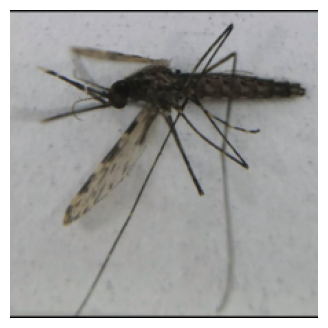

In [43]:
# --- Model Factory (Same as in your training notebook) ---
def get_model(model_name, num_outputs):
    model = None

    if model_name == 'resnet50':
        model = models.resnet50(weights='DEFAULT')
        model.fc = nn.Linear(model.fc.in_features, num_outputs)

    elif model_name == 'mobilenet_v3':
        model = models.mobilenet_v3_large(weights='DEFAULT')
        in_features = model.classifier[3].in_features
        model.classifier[3] = nn.Linear(in_features, num_outputs)

    elif model_name == 'efficientnet_b2':
        model = models.efficientnet_b2(weights='DEFAULT')
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, num_outputs)

    elif model_name == 'convnext_tiny':
        model = models.convnext_tiny(weights='DEFAULT')
        in_features = model.classifier[2].in_features
        model.classifier[2] = nn.Linear(in_features, num_outputs)

    elif model_name == 'vit_b_16':
        model = models.vit_b_16(weights='DEFAULT')
        in_features = model.heads.head.in_features
        model.heads.head = nn.Linear(in_features, num_outputs)

    return model

# --- Data Transform (Validation/Inference only) ---
INFERENCE_TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# --- Dataset Class (Simplified for Inference) ---
class InferenceDataset(Dataset):
    def __init__(self, csv_file, image_dir, transform=None):
        self.labels_df = pd.read_csv(csv_file)
        self.image_dir = image_dir
        self.transform = transform
        self.feature_columns = self.labels_df.columns.drop([FILENAME_COLUMN, EXTRA_COLUMN_TO_DROP, 'file_exists']) # Needed for label length check

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        relative_img_path = self.labels_df.loc[idx, FILENAME_COLUMN]
        full_img_path = os.path.join(self.image_dir, relative_img_path + IMAGE_EXTENSION)
        image = Image.open(full_img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        # We return the raw index and image for the inference script
        return image, idx

# --- Loading the Model and Data ---
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# 1. Load the Model Architecture
model = get_model(MODEL_TO_USE, NUM_OUTPUTS).to(device)

# 2. Load the Model Weights
weights_path = os.path.join(BASE_DIR, f"model_{MODEL_TO_USE}.pth")
try:
    model.load_state_dict(torch.load(weights_path, map_location=device))
except FileNotFoundError:
    # Exit or raise error here
    raise

model.eval() # Set model to evaluation mode

# 3. Create the Dataset
full_inference_dataset = InferenceDataset(
    csv_file=CLEAN_MANIFEST_PATH,
    image_dir=IMAGE_FOLDER_PATH,
    transform=INFERENCE_TRANSFORM
)

def generate_inference_report(model, dataset, glossary_df, index=None):
    """Runs inference and generates a human-readable report for a single image,
    listing only features that were 'checked' (observable), sorted by confidence."""
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    model.eval()

    # Picking an Image
    if index is None:
        index = np.random.randint(0, len(dataset))

    image, _ = dataset[index]
    image_input = image.unsqueeze(0).to(device)

    # Running the Model
    with torch.no_grad():
        outputs = model(image_input)
        probs = torch.sigmoid(outputs).cpu().numpy()[0]

    # Generating the Report
    print(f"ENTOMOLOGIST REPORT (Model: {MODEL_TO_USE.upper()})")
    print(f"Image Index in CSV: {index}")
    print("-" * 60)

    description_lines = []

    # Looping through the glossary rows (which defines the feature names)
    for i, feature_id in enumerate(glossary_df.index):
        # Even Index: The 'checked' status (0 or 1)
        check_idx = (i * 2)
        # Odd Index: The feature 'value' probability (0.0 to 1.0)
        value_idx = (i * 2) + 1

        # Safety check: Ensure indices are within the model output length
        if value_idx >= len(probs):
            break
            
        # --- NEW LOGIC: Filter out unchecked features ---
        # The 'checked' output is a probability, so we convert it to 0 or 1
        checked_prob = probs[check_idx]
        checked_value = 1 if checked_prob > 0.5 else 0

        if checked_value == 0:
            # If the model predicts the feature is NOT observable, skip this feature
            continue
        # -------------------------------------------------

        prob = probs[value_idx]

        # Determine the binary prediction and confidence for the observable feature
        if prob > 0.5:
            # Model predicts the feature is PRESENT (1)
            predicted_value = '1'
            text = glossary_df.loc[feature_id, predicted_value]
            confidence = prob
        else:
            # Model predicts the feature is NOT PRESENT (0)
            predicted_value = '0'
            text = glossary_df.loc[feature_id, predicted_value]
            confidence = 1.0 - prob # Confidence in the negative prediction
        
        # Add the line to the list
        report_line = f"{text} [Checked: {checked_prob:.0%}, Value Conf: {confidence:.0%}]"
        description_lines.append((confidence, report_line))


    # Sorting by confidence (highest first)
    description_lines.sort(key=lambda x: x[0], reverse=True)

    # Printing all features, sorted by confidence
    print("\nOBSERVABLE FEATURE PREDICTIONS (Sorted by Value Confidence):")
    if not description_lines:
        print("  (No observable features detected by the model)")
    else:
        for confidence, line in description_lines:
            print(textwrap.fill(f"• {line}", width=150, subsequent_indent='  '))


    # Showing the Image (Un-normalizing)
    img_display = image.permute(1, 2, 0).numpy()
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_display = std * img_display + mean
    img_display = np.clip(img_display, 0, 1)

    plt.figure(figsize=(4, 4))
    plt.imshow(img_display)
    plt.axis('off')
    plt.show()

# --- Run Inference ---
generate_inference_report(model, full_inference_dataset, glossary_df)